# Feature Engineering: Revenue Features
By Az-Zahrawani


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def safe_divide(a, b):
    return a / b.replace(0, np.nan)


## Load Data


In [2]:
df = pd.read_csv('../../data_raw_fix/Data_Merged_Fix.csv')

# Standardize columns to match the previous structure
rename_dict = {
    'Video title': 'video_title',
    'Duration': 'duration',
    'Average percentage viewed (%)': 'average_percentage_viewed_pct',
    'Engaged views': 'engaged_views',
    'YouTube Premium (IDR)': 'youtube_premium_idr',
    'Watch Page ads (IDR)': 'watch_page_ads_idr',
    'Estimated AdSense revenue (IDR)': 'estimated_adsense_revenue_idr',
    'YouTube ad revenue (IDR)': 'youtube_ad_revenue_idr',
    'Ad impressions': 'ad_impressions',
    'Playback-based CPM (IDR)': 'playback_based_cpm_idr',
    'CPM (IDR)': 'cpm_idr',
    'Estimated monetized playbacks': 'estimated_monetized_playbacks',
    'RPM (IDR)': 'rpm_idr',
    'Views': 'views',
    'Watch time (hours)': 'watch_time_hours',
    'Subscribers': 'subscribers',
    'Estimated revenue (IDR)': 'estimated_revenue_idr',
    'Impressions': 'impressions',
    'Impressions click-through rate (%)': 'impressions_click_through_rate_pct',
    'Video_ID': 'video_id',
    'TS1_Views': 'ts1_views',
    'TS2_Views': 'ts2_views',
    'TS3_Views': 'ts3_views',
    'TS4_Views': 'ts4_views',
    'Publish_Date_WIB': 'publish_date',
    'Publish_Time_WIB': 'publish_time_wib'
}
df = df.rename(columns=rename_dict)

# Fix missing columns that cause KeyErrors
if 'likes' not in df.columns:
    df['likes'] = df.get('Reactions', 0)
if 'comments' not in df.columns:
    df['comments'] = df.get('Chat messages', 0)
if 'video_duration_sec' not in df.columns:
    df['video_duration_sec'] = df.get('duration', df.get('Duration', 1))


import numpy as np
def parse_duration_to_seconds(val):
    if pd.isna(val) or str(val).strip() == '': return np.nan
    parts = str(val).strip().split(':')
    try:
        parts = [int(p) for p in parts]
        if len(parts) == 3: return parts[0] * 3600 + parts[1] * 60 + parts[2]
        elif len(parts) == 2: return parts[0] * 60 + parts[1]
        return float(parts[0])
    except: return np.nan

if 'Average view duration' in df.columns:
    df['avg_view_duration_sec'] = df['Average view duration'].apply(parse_duration_to_seconds)
    
if 'publish_date' in df.columns:
    df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')



## 1. revenue_per_view
revenue_idr / views


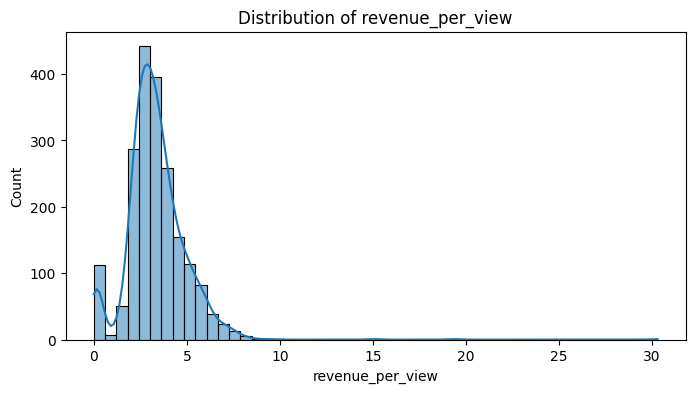

Correlation with views: -0.08746640288433485


In [3]:
if 'revenue_idr' not in df.columns and 'estimated_revenue_idr' in df.columns:
    df['revenue_idr'] = df['estimated_revenue_idr']

df['revenue_per_view'] = safe_divide(df['revenue_idr'], df['views']).fillna(0)

plt.figure(figsize=(8,4))
sns.histplot(df['revenue_per_view'], bins=50, kde=True)
plt.title('Distribution of revenue_per_view')
plt.show()

print('Correlation with views:', df['revenue_per_view'].corr(df['views']))


## 2. revenue_per_subscriber
revenue_idr / subscribers_gained


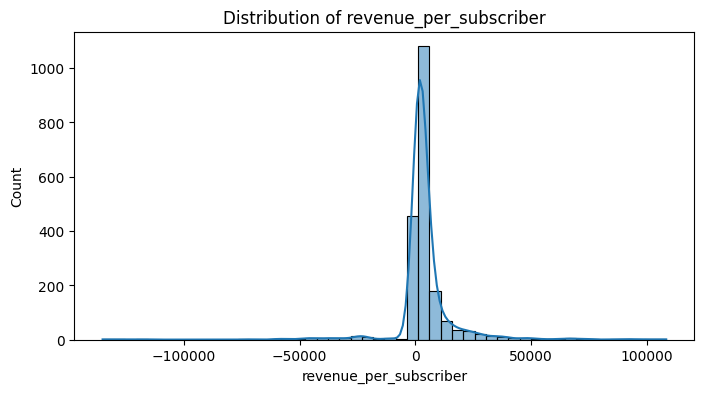

Correlation with views: -0.05525441519945388


In [4]:
df['revenue_per_subscriber'] = safe_divide(df['revenue_idr'], df['subscribers']).fillna(0)

plt.figure(figsize=(8,4))
sns.histplot(df['revenue_per_subscriber'], bins=50, kde=True)
plt.title('Distribution of revenue_per_subscriber')
plt.show()

print('Correlation with views:', df['revenue_per_subscriber'].corr(df['views']))


## 3. monetization_rate
(revenue_idr > 0).astype(int)


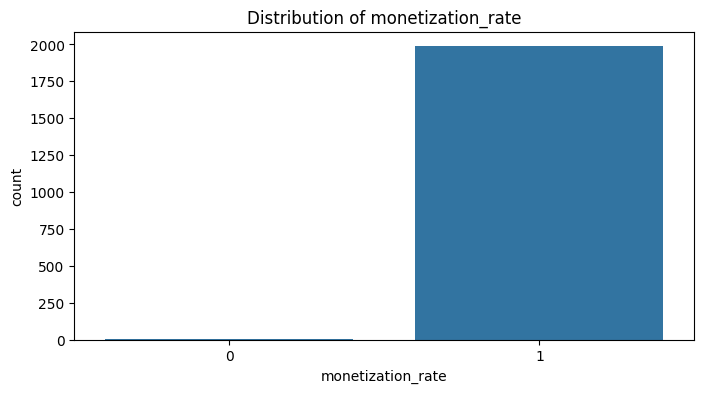

Correlation with views: 0.00978191390834548


In [5]:
df['monetization_rate'] = (df['revenue_idr'] > 0).astype(int)

plt.figure(figsize=(8,4))
sns.countplot(x=df['monetization_rate'])
plt.title('Distribution of monetization_rate')
plt.show()

print('Correlation with views:', df['monetization_rate'].corr(df['views']))


## 4. avg_revenue_category
bin revenue_per_view into Low/Mid/High


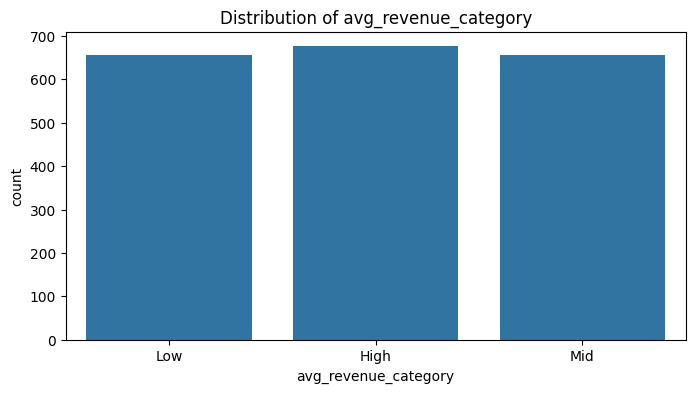

In [6]:
q33 = df['revenue_per_view'].quantile(0.33)
q66 = df['revenue_per_view'].quantile(0.66)

def categorize_rev(x):
    if x <= q33:
        return 'Low'
    elif x <= q66:
        return 'Mid'
    else:
        return 'High'

df['avg_revenue_category'] = df['revenue_per_view'].apply(categorize_rev)

plt.figure(figsize=(8,4))
sns.countplot(x=df['avg_revenue_category'])
plt.title('Distribution of avg_revenue_category')
plt.show()


## Save Features


In [7]:
cols_to_save = ['video_id', 'revenue_per_view', 'revenue_per_subscriber', 'monetization_rate', 'avg_revenue_category']
if 'video_id' in df.columns:
    df[cols_to_save].to_csv('../../data/processed/features_revenue.csv', index=False)
    print('Saved to features_revenue.csv')
else:
    print('video_id not found in dataset')


Saved to features_revenue.csv
